## Lake Zug Retreat Day 3

In [10]:
# imports
import ewgreaders as ewg
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

In [16]:
def load_adcp_chain(di, gap):
    # ADCP
    all_adcp = []
    for _, row in di.iterrows():
        mreader = ewg.mooring_reader.MooringReader(row.lake, row.date, row.location)
        deploy, retrieve = mreader.get_deploy_retrieve_dates()
        t_start = deploy + pd.Timedelta(days=1)
        t_end = retrieve - pd.Timedelta(days=1)
        areader = ewg.adcp_reader.ADCPReader(row.lake, row.date, row.location, row.serial_id)
        ds = areader.load().sel(time=slice(t_start, t_end))
        ds['depth'] = ds['depth'].round(0)
        ds = ewg.signal.valid_depths(ds, 0.5)    # keep depth bins with > 50% data
        all_adcp.append(ds)

    # shared time axis as mean of each instruments times
    time_shared = (np.mean([ds.time.values.astype('int64') for ds in all_adcp], axis=0).astype('datetime64[ns]'))
    all_adcp_aligned = [ds.assign_coords(time=time_shared) for ds in all_adcp]

    # concatenate datasets and average common range bins
    ds_adcp = xr.concat(all_adcp_aligned, dim='depth')
    ds_adcp = ds_adcp.sortby('depth')
    ds_adcp = ds_adcp.groupby('depth').mean()

    # don't interplate over gap from opposite looking ADCPs in double frame
    full_depth = np.sort(np.concatenate([ds_adcp.depth.values, gap]))
    ds_adcp = ds_adcp.reindex(depth=full_depth)

    return ds_adcp

def rolling_average_circular(da, window):
    da_rad = np.deg2rad(da)

    sin = np.sin(da_rad)
    cos = np.cos(da_rad)

    sin_ra = sin.rolling(time=window, center=True).mean()
    cos_ra = cos.rolling(time=window, center=True).mean()

    da_rad_ra = np.arctan2(sin_ra, cos_ra)

    da_ra = np.rad2deg(da_rad_ra)

    return da_ra % 360

In [17]:
lake = 'Zug'
di_m = ewg.get_data_index(lake, 'mooring')

In [14]:
date = '2026-01-14'
loc = 'LZC'
di_m_sel = di_m.query("date == @date and location == @loc and sensor == 'adcp'")

gap = np.arange(67, 77)
ds_adcp = load_adcp_chain(di_m_sel, gap)

C:\Users\herremha\AppData\Local\Temp\ipykernel_40668\485425131.py:3: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  di_m_sel = di_m.query("date == @date and location == @loc and sensor == 'adcp'")
C:\Users\herremha\AppData\Local\Temp\ipykernel_40668\1718629731.py:20: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  ds_adcp = xr.concat(all_adcp_aligned, dim='depth')


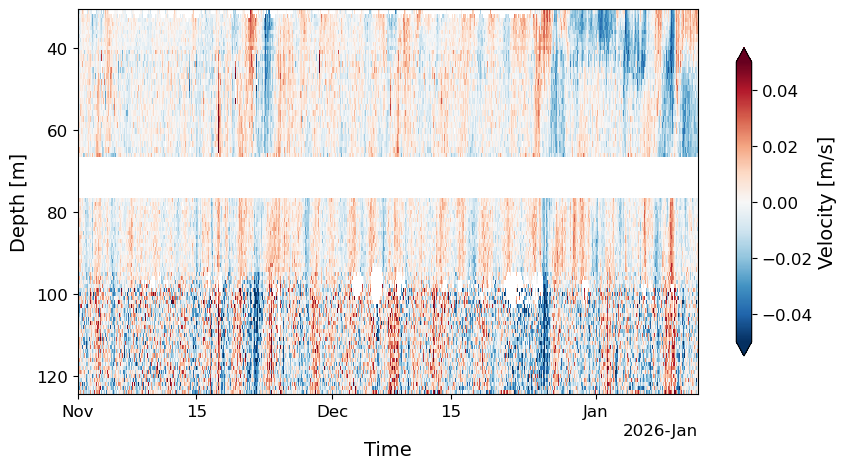

In [24]:
fig, ax = plt.subplots(figsize=(10, 5))

pc = ds_adcp.vel.sel(dir='N').plot(x='time', y='depth', cmap='RdBu_r', vmin=-0.05, vmax=0.05, cbar_kwargs={'shrink': 0.8, 'label': 'Velocity [m/s]'}, ax=ax, rasterized=True)
pc.colorbar.ax.yaxis.label.set_size(14)
pc.colorbar.ax.tick_params(labelsize=12)

ax.set_xlabel('Time', fontsize=14, labelpad=15)
ax.set_ylabel('Depth [m]', fontsize=14, labelpad=5)
ax.set_title('')
ax.tick_params(axis='both', labelsize=12)
ax.xaxis.get_offset_text().set_fontsize(12)

ax.invert_yaxis()

plt.savefig('../gallery/zug_retreat/seiche_ts.svg', bbox_inches='tight')
plt.show()

In [18]:
all_ds = []
for year in ['2025', '2026']:
    meteo_path = f'Q:/Messdaten/Aphys_Hypothesis_data/{lake}/{year}/Meteo/meteo_cham.nc'
    ds = xr.open_dataset(meteo_path)
    all_ds.append(ds)

ds_meteo = xr.concat(all_ds, dim='time')
ds_meteo = ds_meteo.sel(time=slice(ds_adcp.time.values[0], ds_adcp.time.values[-1]))

# wind speed, 1-day rolling average
wind_speed = ds_meteo['wind_speed']
wind_speed_ra = wind_speed.rolling(time=6*24, center=True).mean()

# wind direction, 1-day rolling average, u/v projections
wind_dir = ds_meteo['wind_direction']
wind_dir_ra = rolling_average_circular(wind_dir, 6*24)
wind_dir_rad = np.deg2rad(wind_dir_ra)
u_wind_ra = -wind_speed_ra * np.sin(wind_dir_rad)
v_wind_ra = -wind_speed_ra * np.cos(wind_dir_rad)

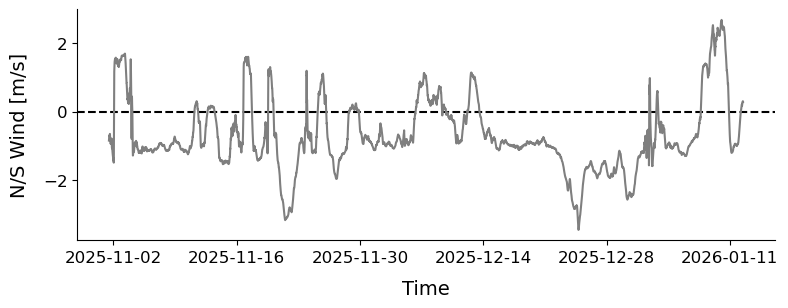

In [25]:
fig, ax = plt.subplots(figsize=(9, 3))

# N/S wind projection
ax.axhline(0, color='black', linestyle='--')
sns.lineplot(x=v_wind_ra.time, y=v_wind_ra, color='tab:gray', ax=ax)

ax.set_xlabel('Time', fontsize=14, labelpad=10)
ax.set_ylabel('N/S Wind [m/s]', fontsize=14, labelpad=10)
ax.xaxis.set_major_locator(mdates.DayLocator(interval=14))
ax.tick_params(axis='both', labelsize=12)
ax.spines[['right', 'top']].set_visible(False)

plt.savefig('../gallery/zug_retreat/ns_wind.svg', bbox_inches='tight')
plt.show()